# Setup

To avoid exceeding the 10GB quota on the home directory, the environment and package paths were moved to the scratch space:

```bash
conda config --add envs_dirs ${SCRATCH}/.conda/envs
conda config --add pkgs_dirs ${SCRATCH}/.conda/pkgs
```

Then, the environment was created with the necessary packages:

```bash
conda create -n lab02_env python=3.10 tensorflow cupy jupyter pandas matplotlib -c conda-forge -y
```

At the end, I verified that the environment was created successfully:

```bash
conda env list
```

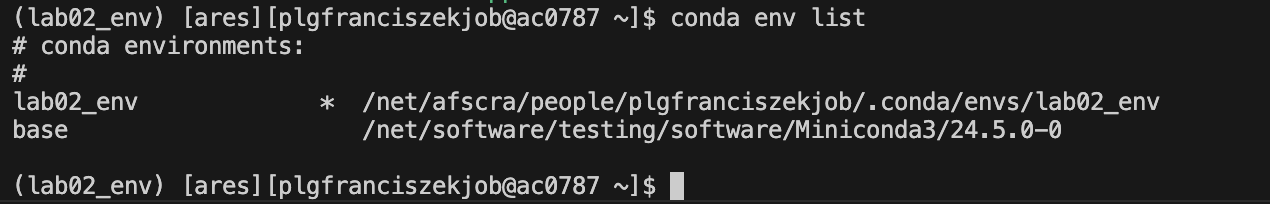

I run jupyter with

```bash
jupyter notebook --no-browser --port=8888 --ip=$(hostname)
```

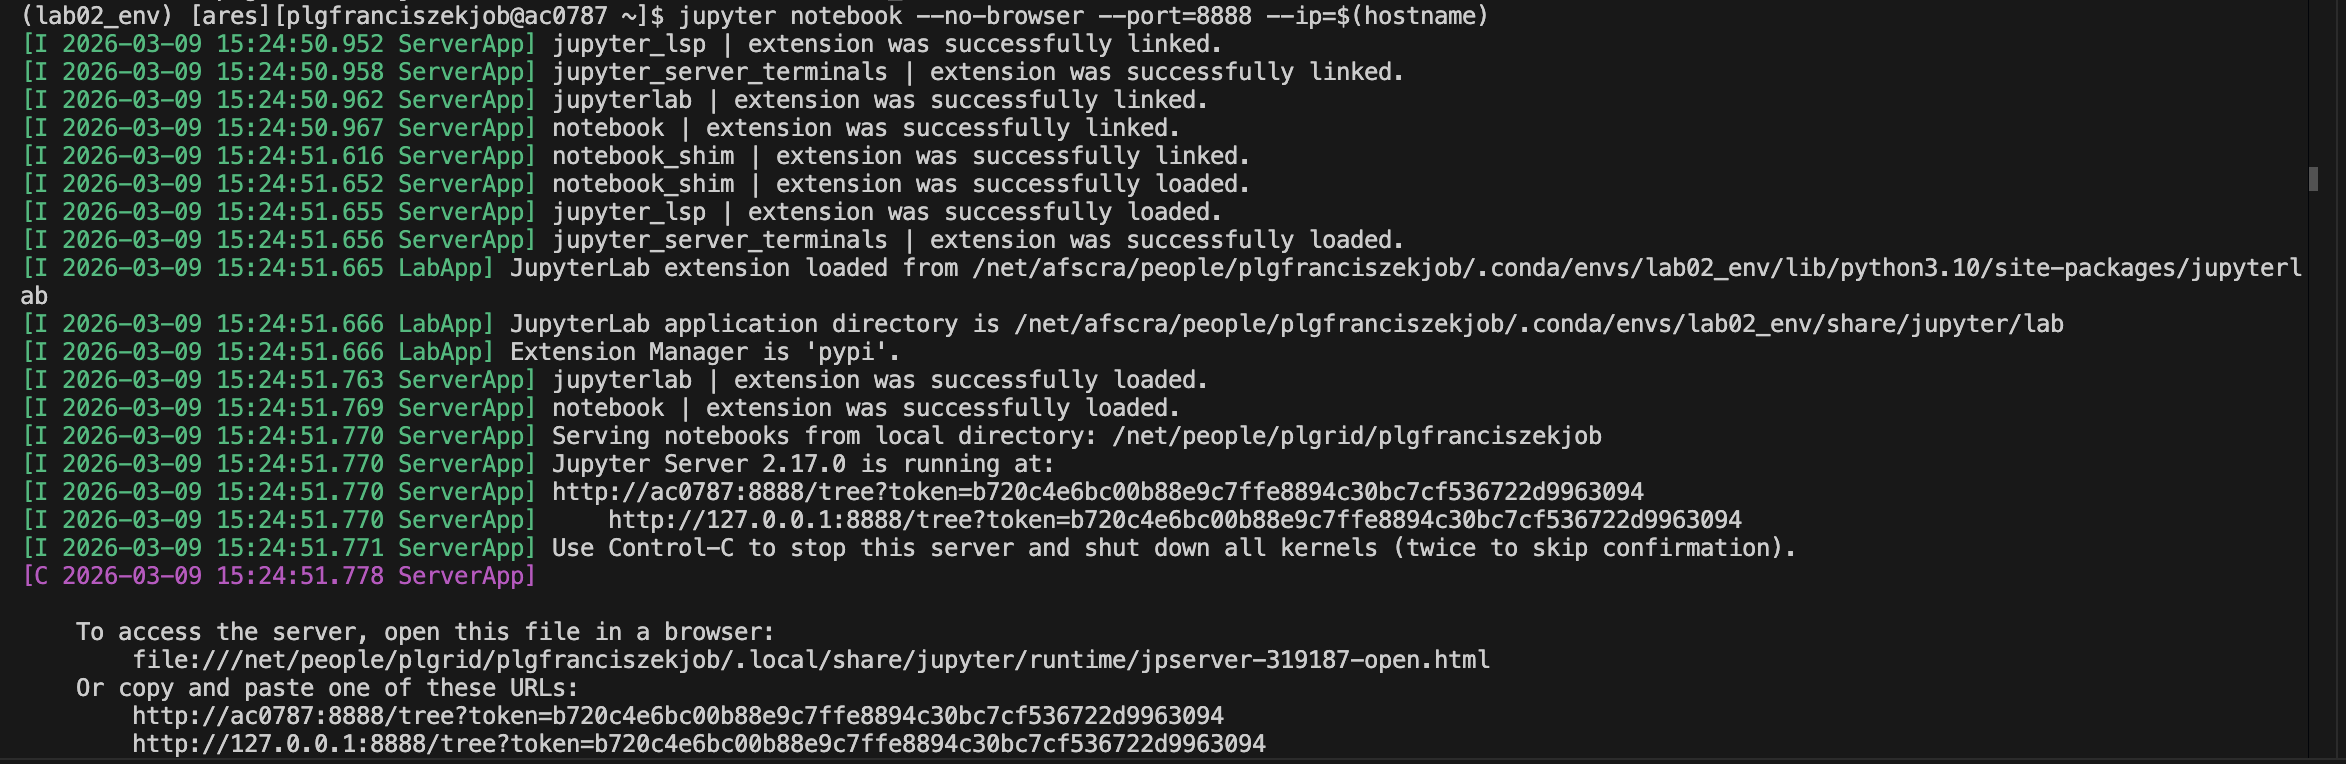

In [ ]:
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense |  Flatten

# Load and preprocess the data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print(physical_devices)

# Define the model
model = Sequential([
Flatten(input_shape=(28, 28)),
Dense(128, activation='relu'),
Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

[]
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9272 - loss: 0.2584
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9665 - loss: 0.1135
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9762 - loss: 0.0788
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9821 - loss: 0.0584
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9864 - loss: 0.0452
313/313 - 0s - 2ms/step - accuracy: 0.9758 - loss: 0.0807

Test accuracy: 0.9757999777793884


In [1]:
import numpy as np
import cupy as cp
import time

def run(N):
    # N is Matrix size
    # CPU-based matrix multiplication using NumPy
    print("-------------------------------")
    print(f"Matrix size: {N}x{N}")
    start_time = time.time()
    A_cpu = np.random.rand(N, N)
    B_cpu = np.random.rand(N, N)
    C_cpu = np.dot(A_cpu, B_cpu)
    print(C_cpu[1][1])
    cpu_time = time.time() - start_time
    print(f"CPU time: {cpu_time:.2f} seconds")
    # GPU-based matrix multiplication using CuPy
    start_time = time.time()
    A_gpu = cp.random.rand(N, N, dtype=cp.float32)
    B_gpu = cp.random.rand(N, N, dtype=cp.float32)
    C_gpu = cp.dot(A_gpu, B_gpu)
    print(C_gpu[1][1])
    gpu_time = time.time() - start_time
    print(f"GPU time: {gpu_time:.2f} seconds")

In [ ]:
# 3 runs with matrix size 10000x10000

for i in range(3):
    run(10000)

-------------------------------
Matrix size: 10000x10000
2484.2582996937654
CPU time: 28.00 seconds
2468.8655
GPU time: 0.16 seconds
-------------------------------
Matrix size: 10000x10000
2521.305539163893
CPU time: 27.98 seconds
2460.2744
GPU time: 0.15 seconds
-------------------------------
Matrix size: 10000x10000
2475.2784122423423
CPU time: 27.99 seconds
2506.5818
GPU time: 0.15 seconds


In [ ]:
# Increasing matrix size to 15000x15000
run(15000)

-------------------------------
Matrix size: 15000x15000
3739.8225582979076
CPU time: 91.90 seconds
3762.7856
GPU time: 0.49 seconds


In [ ]:

# Now decreasing matrix size to 1000x1000
run(1000)

-------------------------------
Matrix size: 1000x1000
258.409383054106
CPU time: 0.31 seconds
262.94064
GPU time: 0.00 seconds


In [2]:
matrix_sizes = [256, 1024, 2048, 4096, 8192, 16384]

for size in matrix_sizes:
    run(size)

-------------------------------
Matrix size: 256x256
59.20754426047178
CPU time: 0.04 seconds
64.606384
GPU time: 1.42 seconds
-------------------------------
Matrix size: 1024x1024
239.41588440157307
CPU time: 0.05 seconds
252.43823
GPU time: 0.00 seconds
-------------------------------
Matrix size: 2048x2048
519.2384829690463
CPU time: 0.32 seconds
506.28778
GPU time: 0.00 seconds
-------------------------------
Matrix size: 4096x4096
1050.7519218312802
CPU time: 2.21 seconds
1023.6846
GPU time: 0.01 seconds
-------------------------------
Matrix size: 8192x8192
2056.8926584264236
CPU time: 16.18 seconds
2058.8691
GPU time: 0.09 seconds
-------------------------------
Matrix size: 16384x16384
4085.3739208778375
CPU time: 123.51 seconds
4088.8362
GPU time: 0.66 seconds


# Interpretation of results

The results I obtained confirm that the CPU performs better with small tasks ($N=256$) due to the absence of
overhead associated with transferring data to an external GPU. However, as the matrix size increases to $N=16384$, the GPU architecture demonstrates its superiority, reducing computation time from 16.23 s to just 0.09 s thanks to the massive number of parallel CUDA cores. For large datasets, the GPU's initialization overhead becomes negligible compared to the gain from massive pipelined processing.

## Summary of results

| Matrix Size (N×N) | CPU Time (s) | GPU Time (s) 
| --- | --- | --- 
| 256 x 256 | 0.00 | 0.03 
| 1024 x 1024 | 0.05 | 0.00 
| 2048 x 2048 | 0.32 | 0.00 
| 4096 x 4096 | 2.21 | 0.01
| 8192 x 8192 | 16.23 | 0.09
| 8192 x 8192 | 16.23 | 0.09
| 16384 x 16384 | 123.51 | 0.66


## Link for full conversation with AI:
https://docs.google.com/document/d/19exSJ12KyJCw8hIXMnedwcO9PBKqp-vHNCn6SpvPLDY/edit?usp=sharing